In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from contextlib import nullcontext

from datetime import datetime

from matplotlib import colormaps

In [2]:
api = wandb.Api()

In [3]:
EXPERIMENT_GROUP = "./artifacts/2024-02-s19/experiments/2-comparison-students"

In [4]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    layers,
    training_size,
    use_val_split,
    contamination_level,
    verbose=False,
    
):
    
    assert use_val_split

    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-s19',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
            {"config.use_val_split": use_val_split},
            {"config.layers": layers}
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics"in run.summary:
            print(">> bad run config")
            print(run.config)
            count += 1
            return run
            continue
                                 
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        datasets.append(run.config["dataset"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
#         best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
#         best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                # remark: this is the actual value used in distillation
                # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                lambda_layer=run.config["policy_lambda_layer"],
                val_acc=best_val_acc, 
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"]
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
        
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
#             "val_agreement": ["mean", "std", "count"],
#             "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        20
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18dims24-16-16-5",
    layers="layer1,layer2,layer3,layer4",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-identity:pca--uncentered",
    training_size=1.0,
    verbose=True,
    contamination_level=0.0,
    use_val_split=True
)

summary

we have 220 runs
df.shape: (11, 5)


lambda_layer   val_acc                 teacher_acc
                     mean       std count        mean
0         0.000  0.707715  0.101158    20      0.9999
1         0.001  0.713026  0.097060    20      0.9999
2         0.010  0.712224  0.104227    20      0.9999
3         0.100  0.718337  0.101647    20      0.9999
4         1.000  0.754108  0.110185    20      0.9999
5        10.000  0.738477  0.114946    20      0.9999
6       100.000  0.754309  0.101991    20      0.9999
7      1000.000  0.750401  0.107908    20      0.9999
8     10000.000  0.749499  0.111195    20      0.9999
9    100000.000  0.750301  0.107096    20      0.9999
10  1000000.000  0.751403  0.105746    20      0.9999

# Comparison on `cifar100-resnet18-v1`

student: resnet18dims24-16-16-5
experiment group: ./artifacts/2024-02-s19/experiments/2-comparison-students
date: 2024-02-08 10:45:30.848856


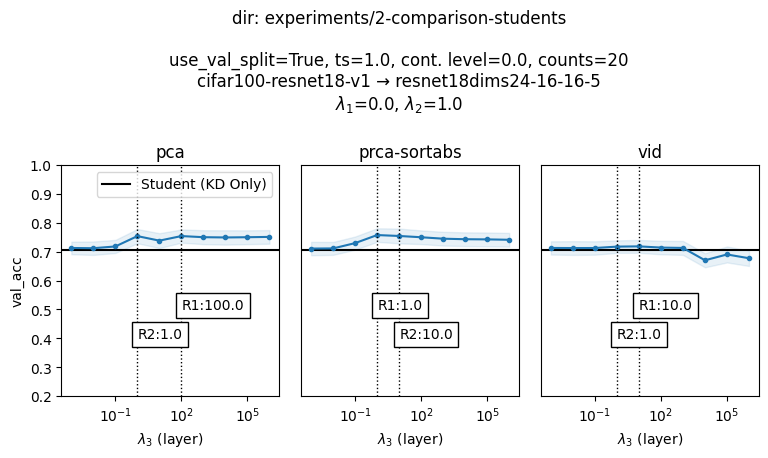

In [6]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def policy_alias(policy):
    
    return policy \
        .replace("basis-identity:", "") \
        .replace("--uncentered", "")

def layer_alias(layers):
    
    _mapping = {
        "layer1,layer2,layer3,layer4": "layer1,2,3,4",
        "layer2,layer3,layer4": "layer2,3,4",
        "layer3,layer4": "layer3,4",
        "layer4": "layer4",
    }
    
    return _mapping.get(layers, layers)

    
def viz_distillation(
    teacher, student, policies,
    show_legend=True,
    arr_layers=[
        "layer1,layer2,layer3,layer4",
#         "layer2,layer3,layer4",
#         "layer3,layer4",
#         "layer4"
    ]
):
        

    contamination_level=0.0

    training_size = 1.0
    use_val_split = True
    lambda_kd = 1.0
    lambda_task = 0.0
            
    col = "val_acc"
    
    cmap = colormaps["Blues"]
    
    cmap_space = np.linspace(0.4, 1, 4)
    cmap_with_normalizer = lambda s: cmap(cmap_space[s])
    
    ncols = len(policies)
    nrows = 1
    
    plt.figure(figsize=(3*ncols, 3*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    print("============")
    print(f"student: {student}")
    print(f"experiment group: {EXPERIMENT_GROUP}")
    print(f"date: {datetime.now()}")
    for pix, policy in enumerate(policies):
        plt.subplot(nrows, ncols, pix+1)
        plt.title(policy_alias(policy))
        
        for lix, layers in enumerate(arr_layers):

            df = read_data(
                teacher=teacher,
                student=student,
                layers=layers,
                policy=policy,
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,
                training_size=training_size,
                contamination_level=contamination_level,
                use_val_split=use_val_split,
                verbose=False
            )


            with nullcontext(enter_result="sanity check"):            
                if count == None:

                    np.testing.assert_equal(
                        df[col]["count"].values,
                        df[col]["count"].values[0]
                    )

                    count = df[col]["count"].values[0]
                else:
                    np.testing.assert_equal(df[col]["count"].values, count)  
                    pass 

                if not (df[col]["count"].values == df[col]["count"].values[0]).all() \
                    or df[col]["count"].values[0] != count:
                        print(f"[warning] policy={policy}:", df[col]["count"].values)    



            if pix > 0:
                try:
                    np.testing.assert_allclose(
                        acc_student_kd_only,
                        df[col]["mean"].values[0],
                        atol=1e-2
                    )
                except Exception as err:
                    print(f"[policy={policy}] acc does not match!")
                    print(err)
            else:
                acc_student_kd_only = df[col]["mean"].values[0]

            if lix == 0:

                plt.axhline(
                    acc_student_kd_only,
                    ls="-",
                    color="k",
                    label="Student (KD Only)"
                )


            # here, we use [1:] to excluding lambda_layer=0
            assert df["lambda_layer"][0] == 0.0
            ticks = df["lambda_layer"][1:].values
            mean = df[col]["mean"][1:].values
            stderr = df[col]["std"][1:].values / (count ** 0.5)

            assert len(ticks) == len(mean)

            plt.plot(
                ticks,
                mean,
                marker=".",
                color=None,
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.1,
                color=plt.gca().lines[-1].get_color()
            )


            plt.ylim([0.2, 1.0])
            plt.xscale("log")
            plt.xlabel("$\lambda_3$ (layer)")
            plt.ylabel(col)
            if pix == 0:
                plt.legend()
                
            for _ix, best_ix in enumerate(np.argsort(-mean)[:2]):
                
                best_lambda_3 = ticks[best_ix]

                plt.axvline(best_lambda_3, ls=":", lw=1, color="k")
                plt.text(
                    best_lambda_3, 0.5 - _ix*0.1, f"R{_ix+1}:{best_lambda_3}",
                    bbox=dict(fc="white")
                )

            if pix % ncols != 0:
                plt.ylabel("")
                plt.yticks([])

    
    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"use_val_split={use_val_split}, ts={training_size}, cont. level={contamination_level}, counts={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
            "",
        ]),
        y=1.4,
    )
    
    plt.subplots_adjust(hspace=0.5, wspace=0.1)


viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18dims24-16-16-5",
    policies = [ 
        f"basis-identity:pca--uncentered",
        f"basis-identity:prca-sortabs--uncentered",
        "vid",
    ],
)

student: resnet18dims32-24-24-5
experiment group: ./artifacts/2024-02-s19/experiments/2-comparison-students
date: 2024-02-07 22:24:54.667453
student: resnet18dims24-16-16-5
experiment group: ./artifacts/2024-02-s19/experiments/2-comparison-students
date: 2024-02-07 22:24:54.747546
student: resnet18dims16-8-8-5
experiment group: ./artifacts/2024-02-s19/experiments/2-comparison-students
date: 2024-02-07 22:24:54.801139


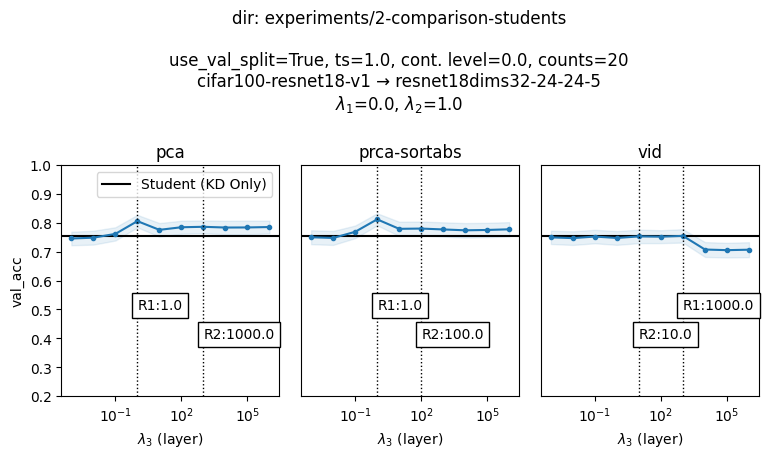

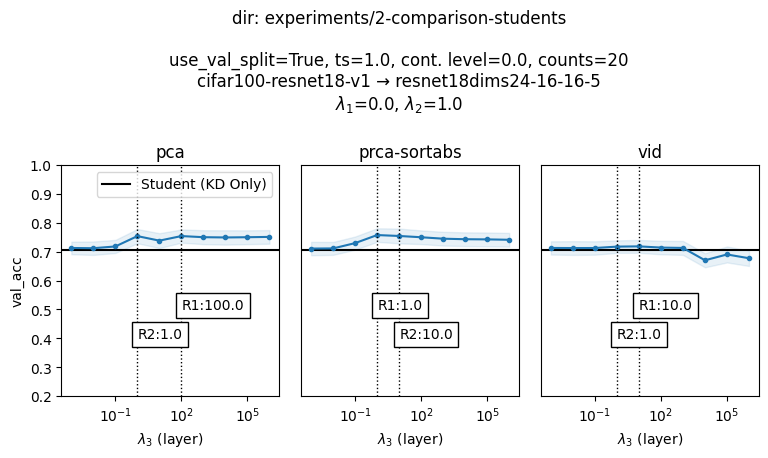

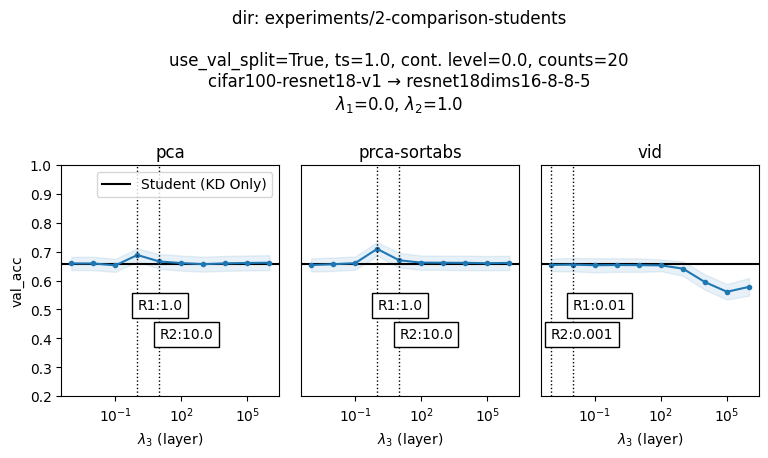

In [48]:
for student in [
    "resnet18dims32-24-24-5",
    "resnet18dims24-16-16-5",
    "resnet18dims16-8-8-5",
]:
    
    viz_distillation(
        teacher = "cifar100-resnet18-v1",
        student=student,
        policies = [ 
            f"basis-identity:pca--uncentered",
            f"basis-identity:prca-sortabs--uncentered",
            "vid",
        ],
    )

# Summary (to write)


*Conclusion:*
- each layer has its own distillation benefit
    - this follows from the observatio that attaching loss at each individual layer improves accuracy over only using KD only.
- having the layer-wise loss at multiple layers generally lead to better performance.